# Q4: Which categories of problems are most common in Zurich? 
This question looks at which category of problem has to most reports related to it. The anticipated workflow is:

0. Import all packages and functions needed
1. Import the data needed
2. Calculate the number of reports per category
3. Create a table of the result
4. Create a bar chart and a pie chart of the result

## 0. Import block

In [2]:
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import cmcrameri.cm as cmc
from pathlib import Path
#from matplotlib_scalebar.scalebar import ScaleBar

import sys
sys.path.append("../scripts")

from functions_zh_wie_neu import import_preprocessed_data #type: ignore
from functions_zh_wie_neu import export_result_to_png #type: ignore

## 1. Import the data
As no cartographic visualisation is created, the only dataset needed is the spatially joined report dataset.


In [11]:
#loading the preprocessed_data
reports_full_sjoin=import_preprocessed_data("reports_quartiere_sjoin.gpkg")

#modify the service_code to finally retreive a nicer table:
reports_full_sjoin["report_category"]=reports_full_sjoin["service_code"]
#display a summary of the dataset to visually check wheter the import worked
reports_full_sjoin.info()

The active geometry column of this geodataframe is called 'geometry'.
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 73243 entries, 0 to 73242
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   service_request_id  73243 non-null  str           
 1   requested_datetime  73243 non-null  datetime64[ms]
 2   e                   73243 non-null  int32         
 3   n                   73243 non-null  int32         
 4   service_code        73243 non-null  str           
 5   description         73243 non-null  str           
 6   index_right         73243 non-null  int64         
 7   qnr                 73243 non-null  int32         
 8   qname               73243 non-null  str           
 9   knr                 73243 non-null  int32         
 10  kname               73243 non-null  str           
 11  geometry            73243 non-null  geometry      
 12  report_category     7324

## 2. Derive the number of reports per category
The category of a report is saved in the 'service_code' column. 

In [12]:
nr_reports_per_category=(reports_full_sjoin
                         .groupby("report_category")
                         .size()
                         .reset_index(name="number_of_reports")
                         .sort_values(by="number_of_reports",ascending=False))

display(nr_reports_per_category)

,report_category,number_of_reports
0,Abfall/Sammelstelle,27627
7,Signalisation/Lichtsignal,11041
8,Strasse/Trottoir/Platz,9910
5,Grünflächen/Spielplätze,7303
2,Beleuchtung/Uhren,5427
1,Allgemein,4016
4,Graffiti,3809
9,VBZ/ÖV,1898
3,Brunnen/Hydranten,1311
6,Schädlinge,901


## 3. Create an exportable table showing the number of reports per category

In [31]:
clean_columns = []

for col in nr_reports_per_category.columns:
    clean_columns.append(col.replace("_", " "))

display(clean_columns)

['report category', 'number of reports']

'File was saved to ..\\outputs\\Q4_table_nrreports_per_category.png.'

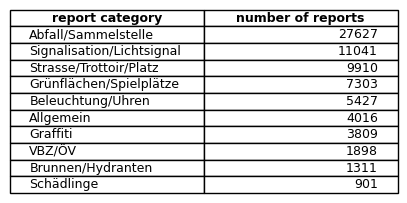

In [41]:
fig, ax =plt.subplots(figsize=(5,1))
ax.axis("off")

#first I want to improve the readability of the column headers
improved_col_headers=[]
for col_header in nr_reports_per_category.columns:
    improved_col_headers.append(col_header.replace("_", " "))

# create the table
overview_table=ax.table(cellText=nr_reports_per_category.values,
         colLabels=improved_col_headers,
         loc="center",
         cellLoc="right")

#further improve aesthetics of the table:
for (row, col), cell in overview_table.get_celld().items():
    #make column titles bold
    if row==0:
        cell.set_text_props(weight="bold")
        continue #to avoid that the text of the column headers are oriented as the text in the cells

    #
    elif col==0:
        cell.get_text().set_ha("left") #set_ha=set_horizontal_alignment

export_result_to_png("Q4_table_nrreports_per_category")


## 4. Visually display this statistics
The table is nice, but humans prefer to see such data visuallised. Therefore, I will create a bar chart and a pie chart to display the results.

In [ ]:
# Bar Chart

In [ ]:
# Pie Chart